# **Preprocesamiento de Datos**

## Objetivo


En este notebook procesamos las señales crudas del dataset MIT-BIH para
convertirlas en un formato que pueda consumir la CNN.

El proceso tiene cuatro pasos:
1. Segmentación de latidos individuales
2. Binarización de etiquetas (Normal vs Anormal)
3. División en train / val / test
4. Normalización de las señales

## Configuración

In [4]:
!pip install wfdb

import wfdb
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
from sklearn.model_selection import train_test_split

# Semilla para reproducibilidad
np.random.seed(42)

# Trabajamos desde el directorio actual
print("Directorio de trabajo:", os.getcwd())

records = [
    "100","101","102","103","104","105","106","107","108","109",
    "111","112","113","114","115","116","117","118","119",
    "121","122","123","124","200","201","202","203","205","207",
    "208","209","210","212","213","214"
]

Directorio de trabajo: /


In [5]:
# Descargamos los registros desde PhysioNet
wfdb.dl_database("mitdb", dl_dir="mitdb", records=records)
print("Descarga completada:", os.listdir("mitdb")[:6], "...")

Generating record list for: 100
Generating record list for: 101
Generating record list for: 102
Generating record list for: 103
Generating record list for: 104
Generating record list for: 105
Generating record list for: 106
Generating record list for: 107
Generating record list for: 108
Generating record list for: 109
Generating record list for: 111
Generating record list for: 112
Generating record list for: 113
Generating record list for: 114
Generating record list for: 115
Generating record list for: 116
Generating record list for: 117
Generating record list for: 118
Generating record list for: 119
Generating record list for: 121
Generating record list for: 122
Generating record list for: 123
Generating record list for: 124
Generating record list for: 200
Generating record list for: 201
Generating record list for: 202
Generating record list for: 203
Generating record list for: 205
Generating record list for: 207
Generating record list for: 208
Generating record list for: 209
Generati

## 1. Segmentación de latidos

Cada latido se extrae centrando una ventana de 0.8 segundos en el pico R
(el punto máximo del complejo QRS anotado por los cardiólogos).

A 360 Hz, 0.8 segundos equivalen a 288 muestras por latido.

Se descartan las anotaciones que no corresponden a latidos reales
(ruido, cambios de ritmo, marcadores técnicos).

In [6]:
def load_record(record_id, base_dir="mitdb", channel=0, window_sec=0.8, target_size=288):
    """
    Carga un registro y extrae ventanas centradas en cada latido anotado.

    Parámetros:
    - record_id: identificador del registro (ej. "100")
    - channel: canal de la señal (0 = derivación MLII)
    - window_sec: duración de la ventana en segundos
    - target_size: número de muestras por ventana (window_sec * fs)
    """
    record = wfdb.rdrecord(f"{base_dir}/{record_id}")
    ann    = wfdb.rdann(f"{base_dir}/{record_id}", "atr")

    signal = record.p_signal[:, channel]
    fs     = record.fs

    window_size = int(window_sec * fs)
    half        = window_size // 2

    X_local = []
    y_local = []

    for sample, symbol in zip(ann.sample, ann.symbol):
        # Descartamos anotaciones que no son latidos
        if symbol in ["+", "~", "|", "/"]:
            continue

        start = sample - half
        end   = sample + half

        # Solo añadimos si la ventana está completa dentro de la señal
        if start > 0 and end < len(signal):
            beat = signal[start:end]
            if len(beat) == target_size:
                X_local.append(beat)
                y_local.append(symbol)

    return np.array(X_local), np.array(y_local)

In [7]:
# Aplicamos la segmentación a todos los registros
X_all = []
y_all = []

for r in records:
    Xr, yr = load_record(r)
    print(f"Registro {r}: {Xr.shape[0]} latidos | Clases: {set(yr)}")
    X_all.append(Xr)
    y_all.append(yr)

X_all = np.concatenate(X_all)
y_all = np.concatenate(y_all)

print(f"\nTotal latidos extraídos: {X_all.shape[0]}")
print(f"Clases únicas: {set(y_all)}")

Registro 100: 2271 latidos | Clases: {np.str_('A'), np.str_('N'), np.str_('V')}
Registro 101: 1864 latidos | Clases: {np.str_('A'), np.str_('N'), np.str_('Q')}
Registro 102: 159 latidos | Clases: {np.str_('V'), np.str_('N'), np.str_('f')}
Registro 103: 2083 latidos | Clases: {np.str_('A'), np.str_('N')}
Registro 104: 849 latidos | Clases: {np.str_('V'), np.str_('N'), np.str_('Q'), np.str_('f')}
Registro 105: 2572 latidos | Clases: {np.str_('N'), np.str_('Q'), np.str_('V')}
Registro 106: 2027 latidos | Clases: {np.str_('N'), np.str_('V')}
Registro 107: 59 latidos | Clases: {np.str_('V')}
Registro 108: 1773 latidos | Clases: {np.str_('V'), np.str_('F'), np.str_('x'), np.str_('A'), np.str_('j'), np.str_('N')}
Registro 109: 2530 latidos | Clases: {np.str_('L'), np.str_('F'), np.str_('V')}
Registro 111: 2124 latidos | Clases: {np.str_('L'), np.str_('V')}
Registro 112: 2537 latidos | Clases: {np.str_('A'), np.str_('N')}
Registro 113: 1794 latidos | Clases: {np.str_('a'), np.str_('N')}
Regist

## Análisis exploratorio de las clases

Antes de binarizar revisamos la distribución de clases para entender
el desbalance del dataset.

In [8]:
# Distribución multiclase
unique, counts = np.unique(y_all, return_counts=True)
class_distribution = pd.DataFrame({
    "Clase"     : unique,
    "Cantidad"  : counts,
    "Porcentaje": counts / counts.sum() * 100
}).sort_values("Cantidad", ascending=False)

print(class_distribution.to_string(index=False))

Clase  Cantidad  Porcentaje
    N     52242   70.849099
    L      8071   10.945658
    R      5605    7.601340
    V      4672    6.336032
    F       775    1.051033
    A       769    1.042896
    f       722    0.979156
    !       472    0.640113
    a       149    0.202070
    E       106    0.143754
    x        58    0.078658
    Q        33    0.044754
    J        32    0.043397
    j        16    0.021699
    ]         6    0.008137
    [         6    0.008137
    S         2    0.002712
    "         1    0.001356


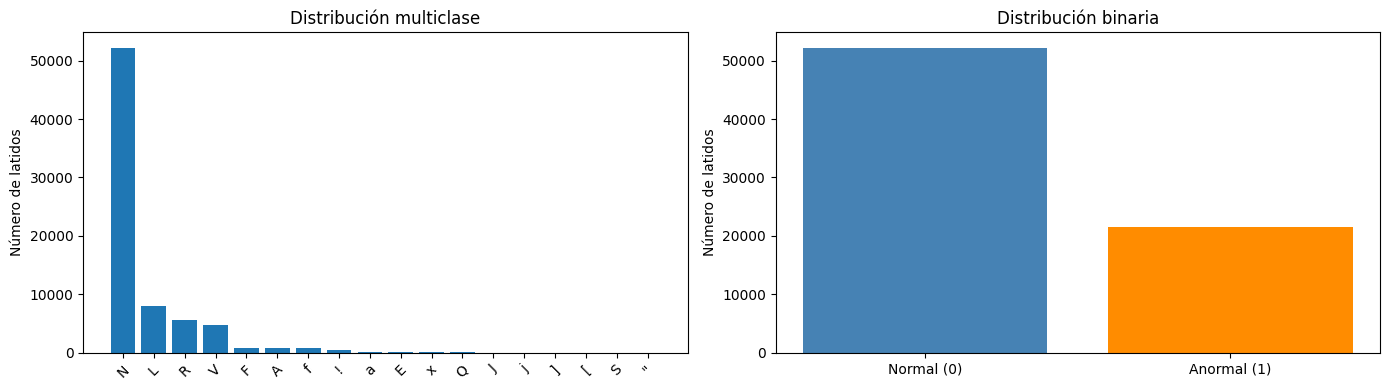


Normal:  52,242 (70.8%)
Anormal: 21,495 (29.2%)


In [9]:
# Visualización de la distribución multiclase y binaria
y_binary_temp = np.where(y_all == "N", 0, 1)
unique_bin, counts_bin = np.unique(y_binary_temp, return_counts=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].bar(class_distribution["Clase"], class_distribution["Cantidad"])
axes[0].set_title("Distribución multiclase")
axes[0].tick_params(axis='x', rotation=45)
axes[0].set_ylabel("Número de latidos")

axes[1].bar(["Normal (0)", "Anormal (1)"], counts_bin, color=["steelblue", "darkorange"])
axes[1].set_title("Distribución binaria")
axes[1].set_ylabel("Número de latidos")

plt.tight_layout()
plt.show()

print(f"\nNormal:  {counts_bin[0]:,} ({counts_bin[0]/len(y_binary_temp)*100:.1f}%)")
print(f"Anormal: {counts_bin[1]:,} ({counts_bin[1]/len(y_binary_temp)*100:.1f}%)")

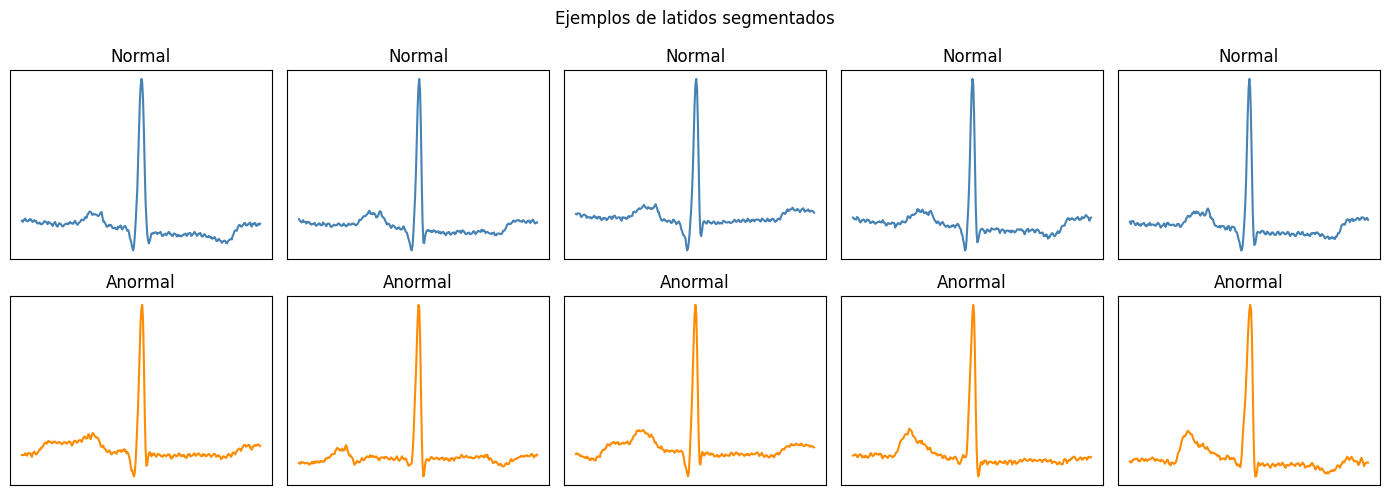

In [10]:
# Visualizamos ejemplos de latidos normales y anormales
normal_indices   = np.where(y_binary_temp == 0)[0][:5]
abnormal_indices = np.where(y_binary_temp == 1)[0][:5]

fig, axes = plt.subplots(2, 5, figsize=(14, 5))

for i, idx in enumerate(normal_indices):
    axes[0, i].plot(X_all[idx], color="steelblue")
    axes[0, i].set_title("Normal")
    axes[0, i].set_xticks([])
    axes[0, i].set_yticks([])

for i, idx in enumerate(abnormal_indices):
    axes[1, i].plot(X_all[idx], color="darkorange")
    axes[1, i].set_title("Anormal")
    axes[1, i].set_xticks([])
    axes[1, i].set_yticks([])

plt.suptitle("Ejemplos de latidos segmentados", fontsize=12)
plt.tight_layout()
plt.show()

## 2. Binarización de etiquetas

Convertimos las 18 clases del dataset en una clasificación binaria:
- **0 → Normal (N):** latido sinusal normal
- **1 → Anormal:** cualquier tipo de arritmia o latido atípico

Esta simplificación es coherente con el objetivo del sistema: actuar como
un primer filtro que detecte si hay algo que requiera atención, sin necesidad
de identificar el tipo exacto de arritmia (eso lo hace el LLM).

In [11]:
y_binary = np.where(y_all == "N", 0, 1)

unique, counts = np.unique(y_binary, return_counts=True)
print(f"Normal (0):  {counts[0]:,} latidos")
print(f"Anormal (1): {counts[1]:,} latidos")

Normal (0):  52,242 latidos
Anormal (1): 21,495 latidos


## 3. División train / val / test

Dividimos el dataset en tres conjuntos:
- **70% entrenamiento:** para que el modelo aprenda
- **10% validación:** para monitorizar el entrenamiento época a época
- **20% test:** para la evaluación final del modelo

Usamos `stratify` para asegurar que la proporción de normales y anormales
se mantiene igual en los tres conjuntos.

In [12]:
x_train, x_temp, y_train, y_temp = train_test_split(
    X_all, y_binary, test_size=0.3, random_state=42, stratify=y_binary
)
x_val, x_test, y_val, y_test = train_test_split(
    x_temp, y_temp, test_size=2/3, random_state=42, stratify=y_temp
)

print("Train:", x_train.shape, dict(zip(*np.unique(y_train, return_counts=True))))
print("Val:  ", x_val.shape,   dict(zip(*np.unique(y_val,   return_counts=True))))
print("Test: ", x_test.shape,  dict(zip(*np.unique(y_test,  return_counts=True))))

Train: (51615, 288) {np.int64(0): np.int64(36569), np.int64(1): np.int64(15046)}
Val:   (7374, 288) {np.int64(0): np.int64(5224), np.int64(1): np.int64(2150)}
Test:  (14748, 288) {np.int64(0): np.int64(10449), np.int64(1): np.int64(4299)}


## 4. Normalización

Normalizamos las señales usando la media y la desviación estándar calculadas
**solo sobre el conjunto de entrenamiento**.

Es importante no usar los datos de validación ni de test para calcular estos
estadísticos, ya que eso introduciría data leakage: el modelo tendría
información indirecta sobre datos que no debería haber visto.

In [13]:
# Calculamos media y std SOLO sobre train
media = x_train.mean()
std   = x_train.std()

print(f"Media: {media:.4f}")
print(f"Std:   {std:.4f}")

# Aplicamos la misma normalización a los tres conjuntos
X_train = (x_train - media) / std
X_val   = (x_val   - media) / std
X_test  = (x_test  - media) / std

Media: -0.3540
Std:   0.4797


## Guardado de los datos procesados

Guardamos los arrays en la carpeta `data/` para que el notebook de
entrenamiento pueda cargarlos directamente sin repetir el preprocesamiento.

In [14]:
os.makedirs("data", exist_ok=True)

np.save("data/X_train.npy", X_train)
np.save("data/X_val.npy",   X_val)
np.save("data/X_test.npy",  X_test)
np.save("data/y_train.npy", y_train)
np.save("data/y_val.npy",   y_val)
np.save("data/y_test.npy",  y_test)

print("Archivos guardados en data/:")
for f in os.listdir("data"):
    if f.endswith(".npy"):
        print(" -", f)

Archivos guardados en data/:
 - y_train.npy
 - X_val.npy
 - y_test.npy
 - X_test.npy
 - X_train.npy
 - y_val.npy


## Resumen

| Conjunto | Muestras | Normal | Anormal |
|---|---|---|---|
| Train | 51.615 | 36.569 (70.8%) | 15.046 (29.2%) |
| Val   | 7.374  | 5.224 (70.8%)  | 2.150 (29.2%)  |
| Test  | 14.748 | 10.449 (70.8%) | 4.299 (29.2%)  |

El stratify ha funcionado correctamente: la proporción Normal/Anormal
es idéntica en los tres conjuntos. Los datos están listos para el
entrenamiento. El siguiente notebook realiza el análisis exploratorio
en profundidad.